# 02 - Preprocessing Pipeline

The EDA notebook showed that image resolutions differ between categories and that ground truth masks must stay strictly binary. In this notebook we work out every preprocessing decision that the later experiments share:

1. resizing images to a common resolution with bilinear interpolation
2. resizing masks with nearest neighbour interpolation to keep them binary
3. mask binarization by thresholding
4. pixel normalization (two different schemes, one per model)

We first prototype each step with PIL and NumPy so the effect of every operation is visible, then translate the decisions into the PyTorch dataset class that became `src/datasets.py`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_ROOT = Path('../data/mvtec_ad')
CATEGORIES = ['bottle', 'hazelnut', 'carpet']
IMG_SIZE = 256  # standard MVTec AD benchmark resolution

np.random.seed(42)

## 1. Resizing Images to 256x256

Original resolutions are 900x900 for bottle and 1024x1024 for hazelnut and carpet. We resize everything to 256x256, the standard benchmark size for MVTec AD. For photographic content **bilinear interpolation** is the right choice: it averages neighbouring pixels, producing smooth downsampled images without blocky artifacts.

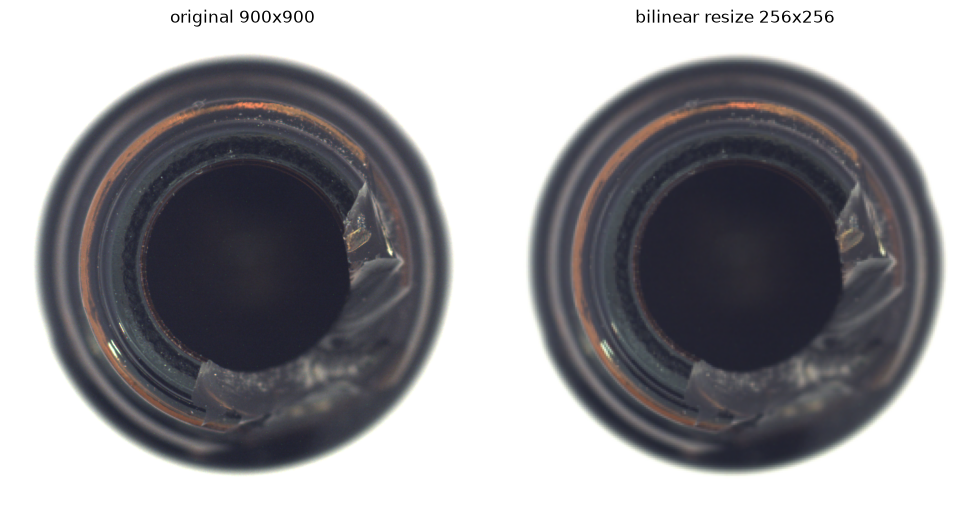

In [2]:
img_path = sorted((DATA_ROOT / 'bottle' / 'test' / 'broken_large').glob('*.png'))[0]
original = Image.open(img_path).convert('RGB')
resized = original.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original)
axes[0].set_title(f'original {original.size[0]}x{original.size[1]}')
axes[0].axis('off')
axes[1].imshow(resized)
axes[1].set_title(f'bilinear resize {IMG_SIZE}x{IMG_SIZE}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 2. Interpolation Choice for Masks: Bilinear vs Nearest

Masks are a different story. A ground truth mask contains only the values 0 and 255. If we resize it with bilinear interpolation the averaging creates **intermediate gray values along the defect boundary**, which are neither defect nor background. Nearest neighbour interpolation copies the closest original pixel instead, so the output stays strictly two valued.

The experiment below resizes the same mask both ways and counts the distinct pixel values in each result.

In [3]:
mask_path = DATA_ROOT / 'bottle' / 'ground_truth' / 'broken_large' / (img_path.stem + '_mask.png')
mask_original = Image.open(mask_path).convert('L')

mask_bilinear = np.asarray(mask_original.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
mask_nearest = np.asarray(mask_original.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))

print(f'original mask unique values:  {np.unique(np.asarray(mask_original)).tolist()}')
print(f'bilinear resize unique count: {len(np.unique(mask_bilinear))} distinct values')
print(f'nearest resize unique values: {np.unique(mask_nearest).tolist()}')

original mask unique values:  [0, 255]
bilinear resize unique count: 230 distinct values
nearest resize unique values: [0, 255]


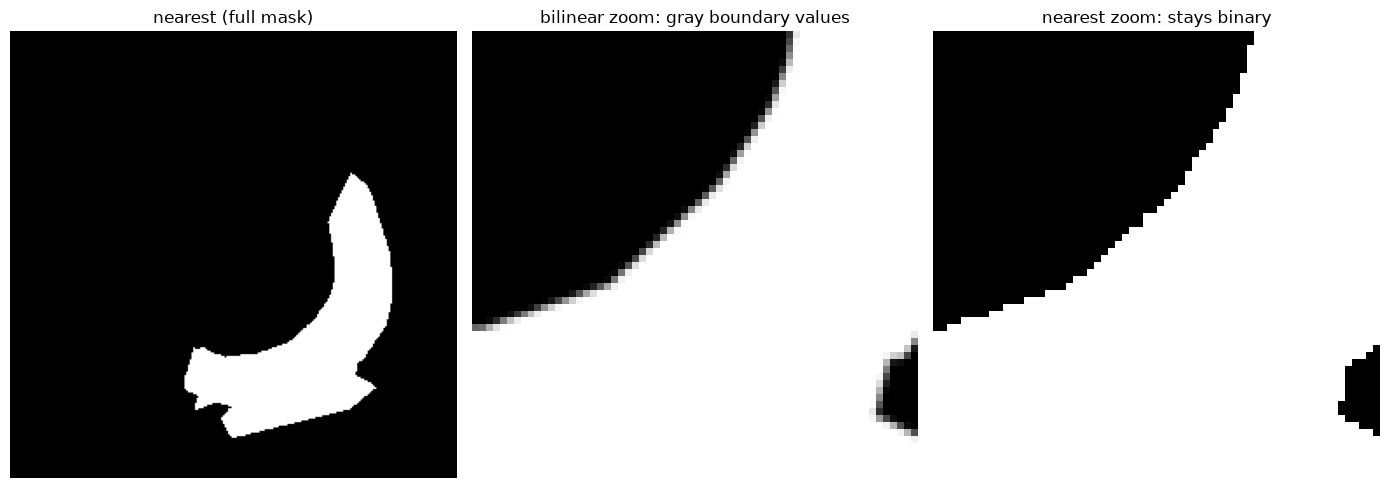

In [4]:
# zoom into a defect boundary to see the gray halo bilinear creates
ys, xs = np.nonzero(mask_nearest)
cy, cx = int(ys.mean()), int(xs.mean())
y0, x0 = max(cy - 32, 0), max(cx - 32, 0)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(mask_nearest, cmap='gray')
axes[0].set_title('nearest (full mask)')
axes[1].imshow(mask_bilinear[y0:y0 + 64, x0:x0 + 64], cmap='gray')
axes[1].set_title('bilinear zoom: gray boundary values')
axes[2].imshow(mask_nearest[y0:y0 + 64, x0:x0 + 64], cmap='gray')
axes[2].set_title('nearest zoom: stays binary')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Mask Binarization

Even with nearest neighbour interpolation we add an explicit threshold at 0.5 after scaling to [0, 1]. This guards against any residual intermediate values introduced by format conversions and guarantees the evaluation code always receives strict 0 or 1 masks.

In [5]:
mask_float = mask_nearest.astype(np.float32) / 255.0
mask_binary = (mask_float > 0.5).astype(np.float32)

print(f'before threshold: min={mask_float.min():.3f} max={mask_float.max():.3f}')
print(f'after threshold:  unique values = {np.unique(mask_binary).tolist()}')
print(f'defect pixels: {int(mask_binary.sum())} of {mask_binary.size} '
      f'({100 * mask_binary.mean():.2f} percent of the image)')

before threshold: min=0.000 max=1.000
after threshold:  unique values = [0.0, 1.0]
defect pixels: 7131 of 65536 (10.88 percent of the image)


## 4. Pixel Normalization: Two Schemes for Two Models

The two models need different input ranges, so the pipeline uses two normalization schemes:

- **Autoencoder:** scale pixels from [0, 255] to **[0, 1]**. The decoder ends in a Sigmoid, so its output lives in [0, 1] and the reconstruction error is only meaningful when the input lives in the same range.
- **PatchCore:** standard **ImageNet normalization** (subtract the channel means, divide by the channel stds) on top of the [0, 1] scaling. The backbone was pretrained on ImageNet with exactly this normalization, so its features are only reliable when inputs follow the same statistics. anomalib applies this internally.

In [6]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

img = np.asarray(resized, dtype=np.float32) / 255.0     # autoencoder input
img_imagenet = (img - IMAGENET_MEAN) / IMAGENET_STD     # PatchCore backbone input

rows = []
for name, arr in [('raw uint8', np.asarray(resized, dtype=np.float32)),
                  ('scaled [0, 1]', img),
                  ('ImageNet normalized', img_imagenet)]:
    rows.append({
        'representation': name,
        'min': round(float(arr.min()), 3),
        'max': round(float(arr.max()), 3),
        'mean R': round(float(arr[..., 0].mean()), 3),
        'mean G': round(float(arr[..., 1].mean()), 3),
        'mean B': round(float(arr[..., 2].mean()), 3),
    })
pd.DataFrame(rows)

,representation,min,max,mean R,mean G,mean B
0,raw uint8,30.000,255.00,138.411,137.633,142.072
1,"scaled [0, 1]",0.118,1.00,0.543,0.540,0.557
2,ImageNet normalized,-1.604,2.64,0.252,0.374,0.672


## 5. The Full Preprocessing Function

Everything above combined into one function: load, resize, normalize the image and load, resize with nearest, binarize the mask. We run it on one sample from each category and overlay the processed mask on the processed image to confirm the two stay spatially aligned after resizing.

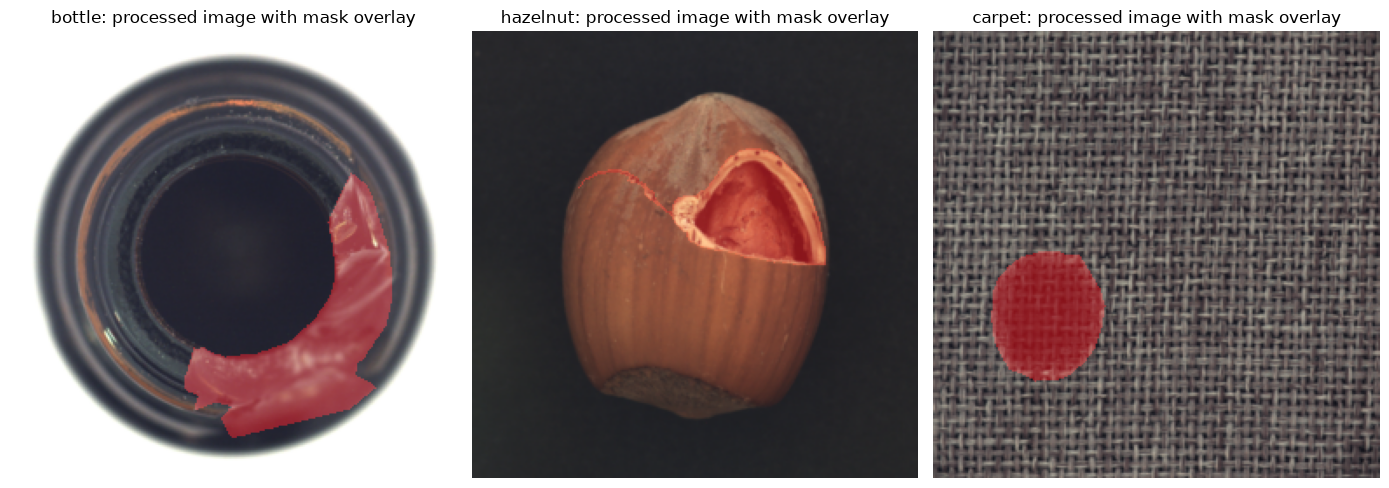

In [7]:
def preprocess_sample(img_path, mask_path=None, img_size=IMG_SIZE):
    """Prototype of the preprocessing used by the whole project."""
    image = Image.open(img_path).convert('RGB').resize((img_size, img_size), Image.BILINEAR)
    image = np.asarray(image, dtype=np.float32) / 255.0

    if mask_path is not None and Path(mask_path).exists():
        mask = Image.open(mask_path).convert('L').resize((img_size, img_size), Image.NEAREST)
        mask = (np.asarray(mask, dtype=np.float32) / 255.0 > 0.5).astype(np.float32)
    else:
        mask = np.zeros((img_size, img_size), dtype=np.float32)

    return image, mask


fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, cat in zip(axes, CATEGORIES):
    defect_dirs = [d for d in sorted((DATA_ROOT / cat / 'test').iterdir())
                   if d.is_dir() and d.name != 'good']
    p = sorted(defect_dirs[0].glob('*.png'))[0]
    mp = DATA_ROOT / cat / 'ground_truth' / defect_dirs[0].name / (p.stem + '_mask.png')
    image, mask = preprocess_sample(p, mp)

    overlay = image.copy()
    red = image.copy(); red[..., 0] = 1.0
    overlay[mask > 0.5] = 0.5 * image[mask > 0.5] + 0.5 * red[mask > 0.5]
    ax.imshow(overlay)
    ax.set_title(f'{cat}: processed image with mask overlay')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. From Prototype to PyTorch Dataset

The decisions above translate directly into torchvision transforms and a PyTorch `Dataset`. Three details worth noting:

- training mode scans only `train/good/` because the task is unsupervised
- test mode reads the label from the folder name and pairs each defective image with its ground truth mask (`<stem>_mask.png`)
- a validation set is split off the training data with a fixed seed of 42 so every experiment sees the same split

These cells need PyTorch, so run this notebook inside the project `.venv` to execute them. The finished version of this code lives in `src/datasets.py`.

In [8]:
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms


def get_transforms():
    # Resize + ToTensor scales pixels to [0, 1], matching the Sigmoid output
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ])


def get_mask_transform():
    # NEAREST keeps masks binary, exactly as validated above
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE),
                          interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(),
    ])


class MVTecDataset(Dataset):
    """MVTec AD loader: train mode uses only good images, test mode
    returns images with labels and ground truth masks."""

    def __init__(self, root, category, split='train'):
        self.root = Path(root)
        self.category = category
        self.split = split
        self.transform = get_transforms()
        self.mask_transform = get_mask_transform()
        self.samples = []
        self._load_samples()

    def _load_samples(self):
        cat_dir = self.root / self.category
        if self.split == 'train':
            for p in sorted((cat_dir / 'train' / 'good').glob('*.png')):
                self.samples.append({'image_path': p, 'mask_path': None,
                                     'label': 0, 'defect_type': 'good'})
        else:
            gt_dir = cat_dir / 'ground_truth'
            for defect_dir in sorted((cat_dir / 'test').iterdir()):
                if not defect_dir.is_dir():
                    continue
                is_normal = defect_dir.name == 'good'
                for p in sorted(defect_dir.glob('*.png')):
                    mask_path = None
                    if not is_normal:
                        candidate = gt_dir / defect_dir.name / (p.stem + '_mask.png')
                        if candidate.exists():
                            mask_path = candidate
                    self.samples.append({'image_path': p, 'mask_path': mask_path,
                                         'label': 0 if is_normal else 1,
                                         'defect_type': defect_dir.name})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        image = self.transform(Image.open(s['image_path']).convert('RGB'))
        if s['mask_path'] is not None:
            mask = self.mask_transform(Image.open(s['mask_path']).convert('L'))
            mask = (mask > 0.5).float()  # explicit binarization
        else:
            mask = torch.zeros(1, IMG_SIZE, IMG_SIZE)
        return {'image': image, 'mask': mask, 'label': s['label'],
                'defect_type': s['defect_type']}

In [9]:
# Reproducible train/val split (10 percent validation) plus dataloaders
full_train = MVTecDataset(DATA_ROOT, 'bottle', split='train')
val_size = max(1, int(len(full_train) * 0.1))
train_ds, val_ds = random_split(
    full_train, [len(full_train) - val_size, val_size],
    generator=torch.Generator().manual_seed(42))
test_ds = MVTecDataset(DATA_ROOT, 'bottle', split='test')

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
batch = next(iter(train_loader))
print(f'train/val/test sizes: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}')
print(f'batch image tensor: {batch["image"].shape}, '
      f'range [{batch["image"].min():.3f}, {batch["image"].max():.3f}]')
print(f'batch mask tensor:  {batch["mask"].shape}, '
      f'unique values {batch["mask"].unique().tolist()}')

train/val/test sizes: 189/20/83
batch image tensor: torch.Size([16, 3, 256, 256]), range [0.114, 1.000]
batch mask tensor:  torch.Size([16, 1, 256, 256]), unique values [0.0]


## 7. Summary

- Images: bilinear resize to 256x256 then scale to [0, 1]. PatchCore additionally gets ImageNet normalization inside anomalib.
- Masks: nearest neighbour resize then threshold at 0.5, keeping them strictly binary.
- Splits: validation is 10 percent of the defect free training images with seed 42, so runs are reproducible.

With preprocessing settled, the next notebook builds and trains the first model, the convolutional autoencoder baseline.